In [1]:
import zarr 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from pyproj import Transformer
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


In [2]:
product_type = "CO"
store_path = "/home/simon/eodc_datasync/private/eodc_logs/s5p/s5p.zarr"

store = zarr.storage.LocalStore(store_path)
group = zarr.group(store=store, path=product_type)

In [ ]:
ds = xr.open_zarr(store_path, group="CO", consolidated=True)
ds

<xarray.Dataset> Size: 465MB
Dimensions:                                (time: 2690, y: 60, x: 90,
                                            spatial_ref: 1)
Coordinates:
  * time                                   (time) datetime64[ns] 22kB 2018-04...
  * y                                      (y) float64 480B 1.8e+06 ... 1.21e+06
  * x                                      (x) float64 720B 4.5e+06 ... 5.39e+06
  * spatial_ref                            (spatial_ref) int8 1B 0
Data variables:
    carbonmonoxide_total_column            (time, y, x) float64 116MB ...
    carbonmonoxide_total_column_corrected  (time, y, x) float64 116MB ...
    carbonmonoxide_total_column_precision  (time, y, x) float64 116MB ...
    qa_value                               (time, y, x) float64 116MB ...
Attributes: (12/36)
    Conventions:                       CF-1.7
    title:                             TROPOMI/S5P CO Column
    freq:                              1D
    platform:                          S5P
    sensor:                            TROPOMI
    spatial_resolution:                10000
    ...                                ...
    product_version:                   1.5.0
    processing_status:                 Nominal
    Status_MET_2D:                     Nominal
    Status_CTM_CO:                     Nominal
    Status_CTMCH4:                     Nominal
    crs_wkt:                           PROJCS["WGS84/Equi7Europe",GEOGCS["WGS...

In [4]:
ds_time_slice = ds.sel(time=slice("2024-01-01", "2024-12-31"))
carbon = ds_time_slice.carbonmonoxide_total_column

ca_valid = carbon.where((~np.isnan(carbon)) & (carbon != -9999))

In [ ]:

eodc_colors = [
    "#083A59",  # Deep Blue
    "#3CBEE0",  # Bright Aqua
    "#A0D7E7",  # Pale Sky Blue
    "#B9D1D6",  # Soft Silver
    "#D1A36B",  # Warm Beige
    "#D88C50",  # Muted Orange
    "#A89255",  # Warm Gold
    "#8B6C32"   # Rich Brown
]

eodc_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", eodc_colors)

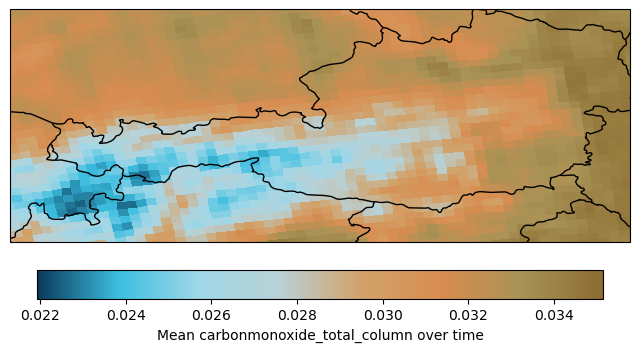

In [6]:
var_name = "carbonmonoxide_total_column"

transformer = Transformer.from_crs("EPSG:27704", "EPSG:4326", always_xy=True)
X, Y = np.meshgrid(ca_valid["x"].values, ca_valid["y"].values)
lons, lats = transformer.transform(X, Y)

mean_image = ca_valid.mean(dim="time").values  # 2D array

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})

ax.add_feature(cfeature.BORDERS, edgecolor='black')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgray')

ax.set_extent([9, 17, 46, 49], crs=ccrs.PlateCarree())

im = ax.pcolormesh(
    lons, lats, mean_image,
    cmap=eodc_cmap, 
    vmin=mean_image.min(), vmax=mean_image.max(),
    transform=ccrs.PlateCarree()
)

cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.046, pad=0.046)
cbar.set_label(f"Mean {var_name} over time")
#plt.savefig("s5p_over_austria.png", transparent=True, bbox_inches='tight', pad_inches=0)
plt.show()
